In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Day13_Restaurant_Branch_Performance_Dataset.csv")
num_cols = df.select_dtypes(include=np.number).columns.tolist()
display(df.head())

,Record_ID,Date,Day,Month,Branch,Region,Store_Type,Staff_Count,Marketing_Spend,Customers,...,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent,Weather,Promotion
0,ST0001,2026-06-06,Saturday,June,Jaipur,North,Express,7,4977.25,172,...,66766.77,27954.29,46554.90,20211.87,29.0,4.44,20.8,70.3,Clear,NaN
1,ST0002,2026-02-10,Tuesday,February,Pune,West,Premium,14,8998.30,285,...,157230.89,63816.59,96813.95,60416.94,27.9,4.56,31.3,70.7,Clear,Loyalty Offer
2,ST0003,2026-03-07,Saturday,March,Delhi,North,Premium,16,10034.97,306,...,155811.96,54874.10,89888.91,65923.05,30.2,4.36,21.4,61.5,Clear,NaN
3,ST0004,2026-05-11,Monday,May,Mumbai,West,Standard,9,5095.84,198,...,80574.05,31429.44,53531.82,27042.23,21.7,4.65,22.9,40.4,Clear,NaN
4,ST0005,2026-01-14,Wednesday,January,Kochi,South,Express,9,6681.82,148,...,56579.89,21759.51,44376.25,12203.64,26.1,4.50,29.0,44.3,Clear,Combo Deal


Dataset Overview

In [2]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nRandom sample:")
display(df.sample(5, random_state=42))

Rows: 350
Columns: 22

Column names:
['Record_ID', 'Date', 'Day', 'Month', 'Branch', 'Region', 'Store_Type', 'Staff_Count', 'Marketing_Spend', 'Customers', 'Orders', 'Average_Bill', 'Revenue', 'Food_Cost', 'Operating_Cost', 'Profit', 'Avg_Delivery_Min', 'Customer_Rating', 'Temperature_C', 'Humidity_Percent', 'Weather', 'Promotion']

Data types:


,Data Type
Record_ID,str
Date,str
Day,str
Month,str
Branch,str
Region,str
Store_Type,str
Staff_Count,int64
Marketing_Spend,float64
Customers,int64



Random sample:


,Record_ID,Date,Day,Month,Branch,Region,Store_Type,Staff_Count,Marketing_Spend,Customers,...,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent,Weather,Promotion
157,ST0158,2026-01-17,Saturday,January,Jaipur,North,Express,6,5612.06,203,...,54603.87,20842.22,37700.90,16902.97,30.8,4.67,31.1,63.2,Cloudy,NaN
341,ST0342,2026-02-28,Saturday,February,Srinagar,North,Standard,11,4954.63,234,...,84869.22,27364.57,54059.87,30809.35,30.1,4.38,35.1,82.8,Cloudy,NaN
315,ST0316,2026-03-02,Monday,March,Delhi,North,Express,5,7361.81,176,...,50394.32,18682.22,37535.31,12859.01,26.0,4.29,29.6,68.7,Cloudy,Combo Deal
234,ST0235,2026-04-30,Thursday,April,Bengaluru,South,Standard,9,2175.17,210,...,56907.29,19229.13,38515.86,18391.43,26.8,4.56,29.3,85.9,Rain,Loyalty Offer
155,ST0156,2026-01-28,Wednesday,January,Kochi,South,Premium,15,9108.32,246,...,121689.13,45137.54,79909.35,41779.78,27.3,4.31,24.1,43.5,Clear,Loyalty Offer


Data Quality Check

In [3]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing Values": missing,
    "Missing %": missing_pct.round(2)
})

display(missing_summary[missing_summary["Missing Values"] > 0])

print("Duplicate rows:", df.duplicated().sum())

df["Date"] = pd.to_datetime(df["Date"])
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())

,Missing Values,Missing %
Promotion,184,52.57


Duplicate rows: 0
Date range: 2026-01-01 to 2026-06-30


Summary Statistics

In [4]:
print("Numerical descriptive statistics:")
display(df.describe().T.round(2))

print("Categorical descriptive statistics:")
display(df.select_dtypes(include="object").describe().T)

Numerical descriptive statistics:


,count,mean,min,25%,50%,75%,max,std
Date,350,2026-03-30 00:37:01.714285,2026-01-01 00:00:00,2026-02-15 00:00:00,2026-03-26 00:00:00,2026-05-16 18:00:00,2026-06-30 00:00:00,NaN
Staff_Count,350.0,11.957143,5.0,9.0,11.0,15.0,24.0,4.338261
Marketing_Spend,350.0,5516.347743,725.35,4339.7275,5393.37,6748.5025,11784.96,2050.906967
Customers,350.0,217.377143,77.0,180.25,213.0,255.75,360.0,56.722524
Orders,350.0,187.054286,71.0,155.0,182.5,218.75,334.0,50.558371
Average_Bill,350.0,388.906371,180.0,337.315,383.485,441.765,623.28,82.488196
Revenue,350.0,86831.799657,20540.76,61261.7175,79766.88,102976.185,194018.92,36644.453901
Food_Cost,350.0,31807.545114,7262.01,22326.6625,28861.325,38370.37,75946.59,13896.888942
Operating_Cost,350.0,56621.444486,20782.38,43797.67,53723.025,63961.2275,111489.14,18467.842215
Profit,350.0,30210.355171,-6924.68,16915.4925,26873.87,39823.7425,89096.19,19508.592192


Categorical descriptive statistics:


C:\Users\jithender\AppData\Local\Temp\ipykernel_16116\3415876352.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.select_dtypes(include="object").describe().T)


,count,unique,top,freq
Record_ID,350,350,ST0001,1
Day,350,7,Tuesday,56
Month,350,6,February,65
Branch,350,8,Srinagar,52
Region,350,3,South,137
Store_Type,350,3,Standard,196
Weather,350,4,Clear,189
Promotion,166,3,Weekend Offer,74


Distribution Analysis

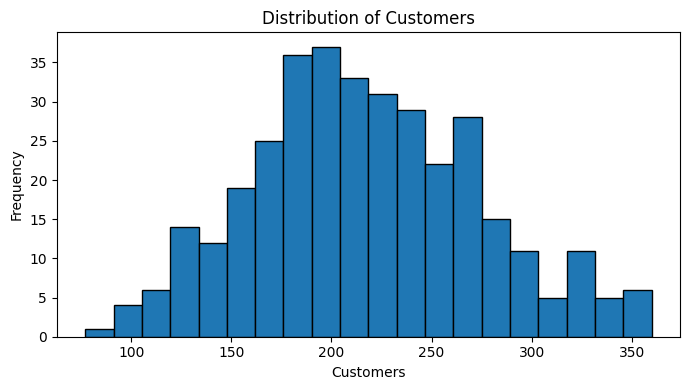

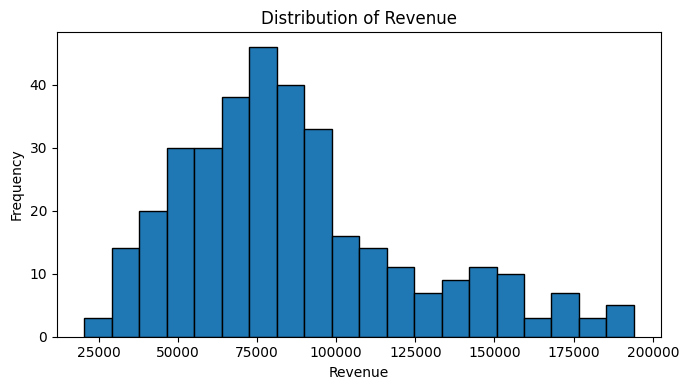

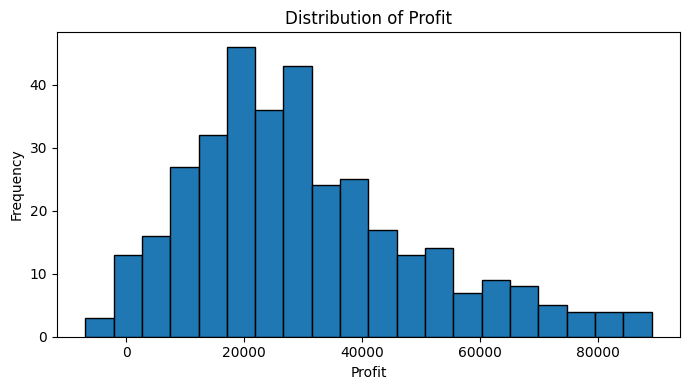

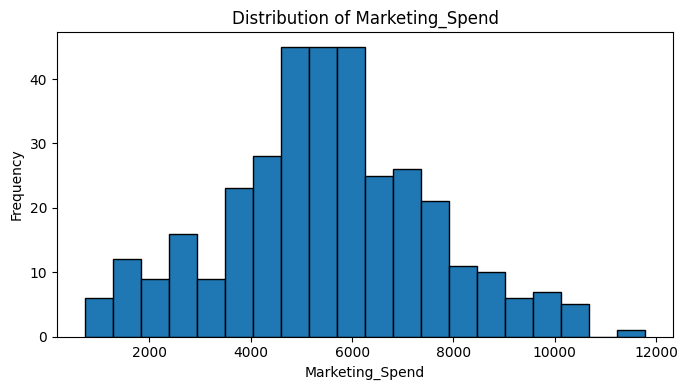

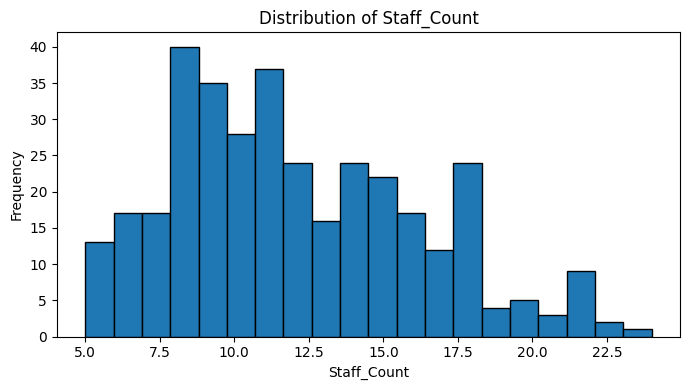

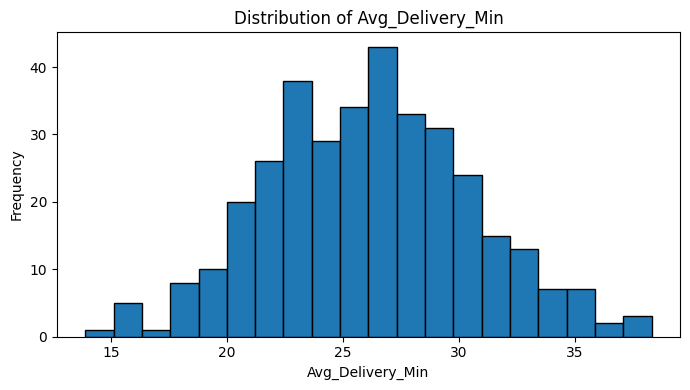

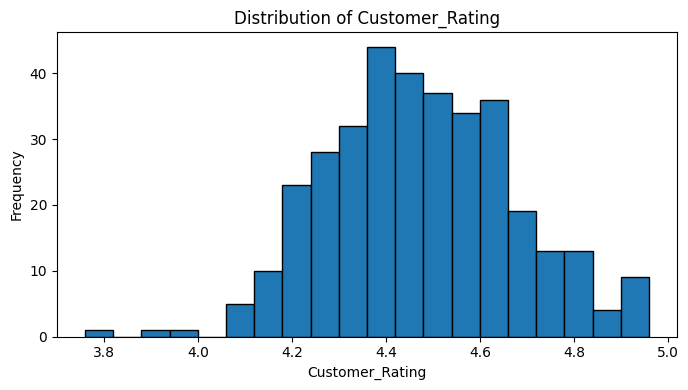

In [5]:
distribution_cols = [
    "Customers", "Revenue", "Profit", "Marketing_Spend",
    "Staff_Count", "Avg_Delivery_Min", "Customer_Rating"
]

for col in distribution_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col], bins=20, edgecolor="black")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

Branch-wise Performance

In [6]:
branch_summary = (
    df.groupby("Branch")
      .agg(
          Records=("Record_ID", "count"),
          Avg_Customers=("Customers", "mean"),
          Avg_Revenue=("Revenue", "mean"),
          Avg_Profit=("Profit", "mean"),
          Avg_Marketing_Spend=("Marketing_Spend", "mean"),
          Avg_Staff=("Staff_Count", "mean"),
          Avg_Delivery_Min=("Avg_Delivery_Min", "mean"),
          Avg_Rating=("Customer_Rating", "mean")
      )
      .sort_values("Avg_Profit", ascending=False)
)

display(branch_summary.round(2))

,Records,Avg_Customers,Avg_Revenue,Avg_Profit,Avg_Marketing_Spend,Avg_Staff,Avg_Delivery_Min,Avg_Rating
Branch,,,,,,,,
Bengaluru,46,227.50,90732.12,31890.91,5413.93,12.85,26.56,4.47
Hyderabad,43,220.79,88804.90,31402.98,5455.15,12.28,25.52,4.47
Delhi,32,213.97,87573.87,31385.30,5762.63,11.56,25.69,4.49
Pune,37,214.92,88107.49,31265.57,5590.57,11.86,25.53,4.54
Jaipur,48,223.27,86746.16,30469.70,5356.64,11.71,26.58,4.47
Srinagar,52,214.73,86746.47,30302.92,5413.67,12.46,25.97,4.48
Kochi,48,209.06,85574.62,28902.04,5660.43,11.83,25.84,4.42
Mumbai,44,213.77,80779.25,26580.99,5580.10,10.89,26.86,4.44


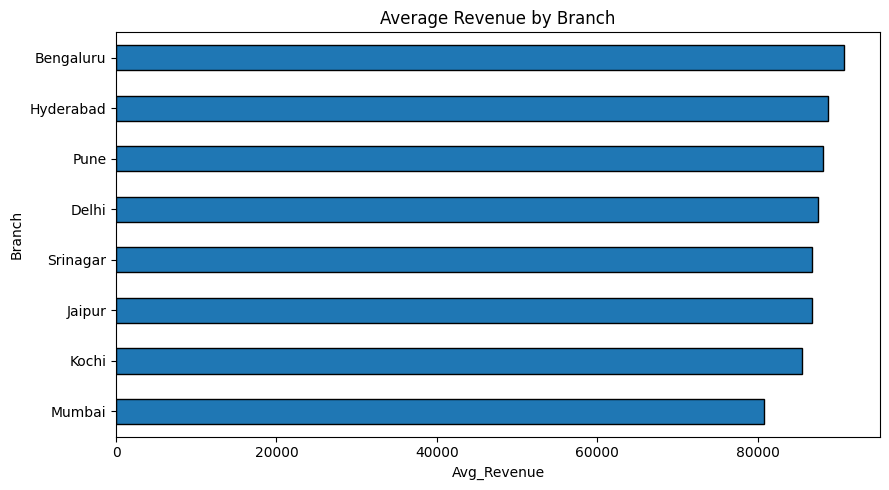

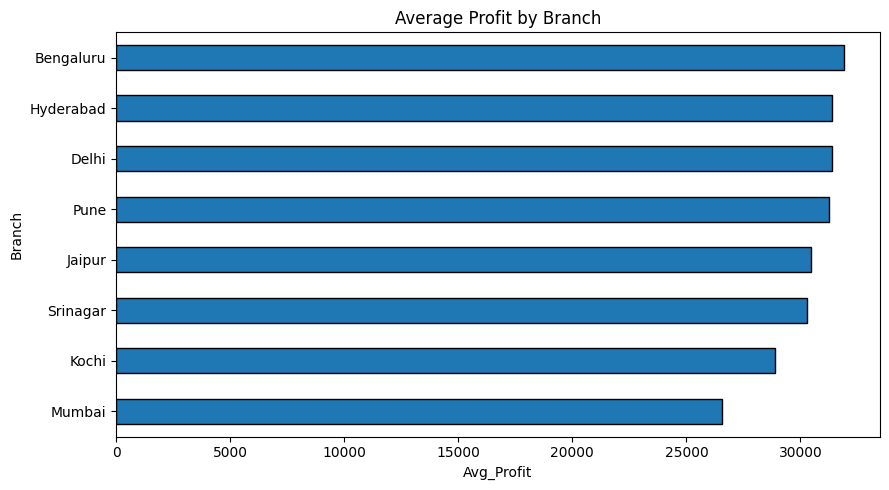

In [7]:
for metric, title in [
    ("Avg_Revenue", "Average Revenue by Branch"),
    ("Avg_Profit", "Average Profit by Branch")
]:
    plt.figure(figsize=(9, 5))
    branch_summary[metric].sort_values().plot(kind="barh", edgecolor="black")
    plt.title(title)
    plt.xlabel(metric)
    plt.ylabel("Branch")
    plt.tight_layout()
    plt.show()

Region-wise Performance

In [8]:
region_summary = (
    df.groupby("Region")
      .agg(
          Records=("Record_ID", "count"),
          Avg_Customers=("Customers", "mean"),
          Avg_Revenue=("Revenue", "mean"),
          Avg_Profit=("Profit", "mean"),
          Avg_Marketing_Spend=("Marketing_Spend", "mean"),
          Avg_Staff=("Staff_Count", "mean"),
          Avg_Delivery_Min=("Avg_Delivery_Min", "mean"),
          Avg_Rating=("Customer_Rating", "mean")
      )
      .sort_values("Avg_Profit", ascending=False)
)

display(region_summary.round(2))

,Records,Avg_Customers,Avg_Revenue,Avg_Profit,Avg_Marketing_Spend,Avg_Staff,Avg_Delivery_Min,Avg_Rating
Region,,,,,,,,
South,137,218.93,88320.22,30690.57,5513.23,12.31,25.98,4.45
North,132,217.65,86946.94,30625.96,5477.53,11.97,26.13,4.48
West,81,214.30,84126.72,28720.86,5584.88,11.33,26.25,4.49


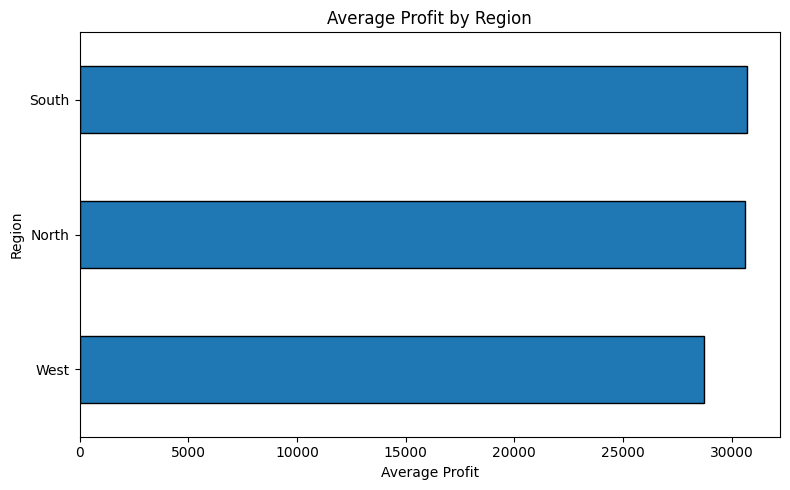

In [9]:
plt.figure(figsize=(8, 5))
region_summary["Avg_Profit"].sort_values().plot(kind="barh", edgecolor="black")
plt.title("Average Profit by Region")
plt.xlabel("Average Profit")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

Store-type Performance

In [10]:
store_summary = (
    df.groupby("Store_Type")
      .agg(
          Records=("Record_ID", "count"),
          Avg_Customers=("Customers", "mean"),
          Avg_Revenue=("Revenue", "mean"),
          Avg_Profit=("Profit", "mean"),
          Avg_Marketing_Spend=("Marketing_Spend", "mean"),
          Avg_Staff=("Staff_Count", "mean"),
          Avg_Delivery_Min=("Avg_Delivery_Min", "mean"),
          Avg_Rating=("Customer_Rating", "mean")
      )
      .sort_values("Avg_Profit", ascending=False)
)

display(store_summary.round(2))

,Records,Avg_Customers,Avg_Revenue,Avg_Profit,Avg_Marketing_Spend,Avg_Staff,Avg_Delivery_Min,Avg_Rating
Store_Type,,,,,,,,
Premium,52,298.73,152867.31,62890.24,8065.56,17.60,26.40,4.46
Standard,196,224.98,87268.67,30630.79,5044.90,12.54,25.98,4.47
Express,102,161.29,52327.16,12742.14,5122.66,7.96,26.17,4.46


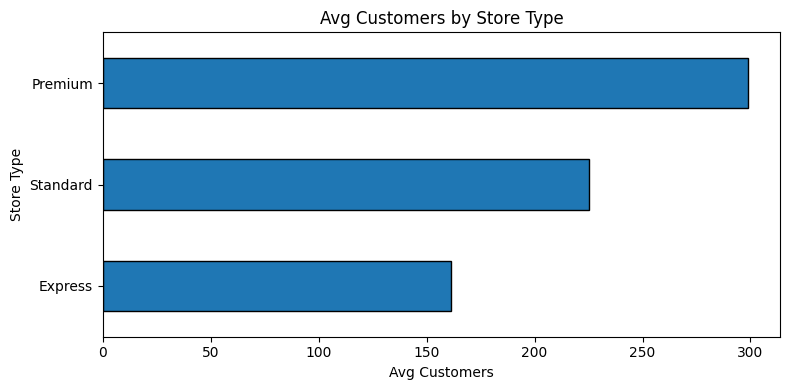

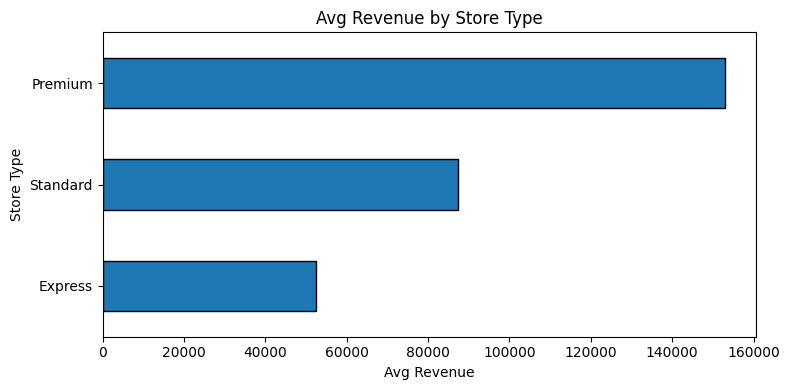

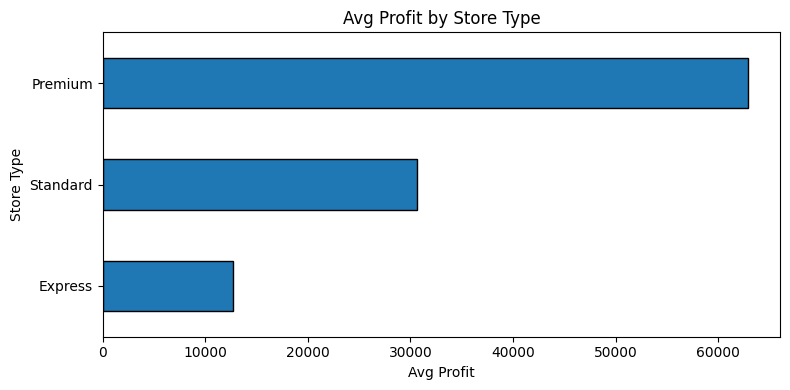

In [11]:
for metric in ["Avg_Customers", "Avg_Revenue", "Avg_Profit"]:
    plt.figure(figsize=(8, 4))
    store_summary[metric].sort_values().plot(kind="barh", edgecolor="black")
    plt.title(f"{metric.replace('_', ' ')} by Store Type")
    plt.xlabel(metric.replace("_", " "))
    plt.ylabel("Store Type")
    plt.tight_layout()
    plt.show()

Correlation Analysis

In [12]:
correlation_matrix = df[num_cols].corr()
display(correlation_matrix.round(2))

,Staff_Count,Marketing_Spend,Customers,Orders,Average_Bill,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent
Staff_Count,1.00,0.28,0.69,0.67,0.52,0.70,0.68,0.79,0.56,-0.18,0.08,0.08,-0.02
Marketing_Spend,0.28,1.00,0.41,0.42,0.33,0.43,0.40,0.49,0.35,0.10,-0.06,0.06,-0.05
Customers,0.69,0.41,1.00,0.98,0.53,0.88,0.84,0.86,0.84,0.18,-0.05,0.00,-0.10
Orders,0.67,0.42,0.98,1.00,0.52,0.86,0.83,0.84,0.82,0.19,-0.05,0.02,-0.09
Average_Bill,0.52,0.33,0.53,0.52,1.00,0.84,0.84,0.80,0.83,-0.03,0.04,-0.05,-0.04
Revenue,0.70,0.43,0.88,0.86,0.84,1.00,0.98,0.96,0.97,0.08,0.01,-0.03,-0.09
Food_Cost,0.68,0.40,0.84,0.83,0.84,0.98,1.00,0.97,0.92,0.08,0.00,-0.03,-0.08
Operating_Cost,0.79,0.49,0.86,0.84,0.80,0.96,0.97,1.00,0.86,0.02,0.02,0.01,-0.07
Profit,0.56,0.35,0.84,0.82,0.83,0.97,0.92,0.86,1.00,0.13,-0.01,-0.06,-0.11
Avg_Delivery_Min,-0.18,0.10,0.18,0.19,-0.03,0.08,0.08,0.02,0.13,1.00,-0.44,0.00,-0.11


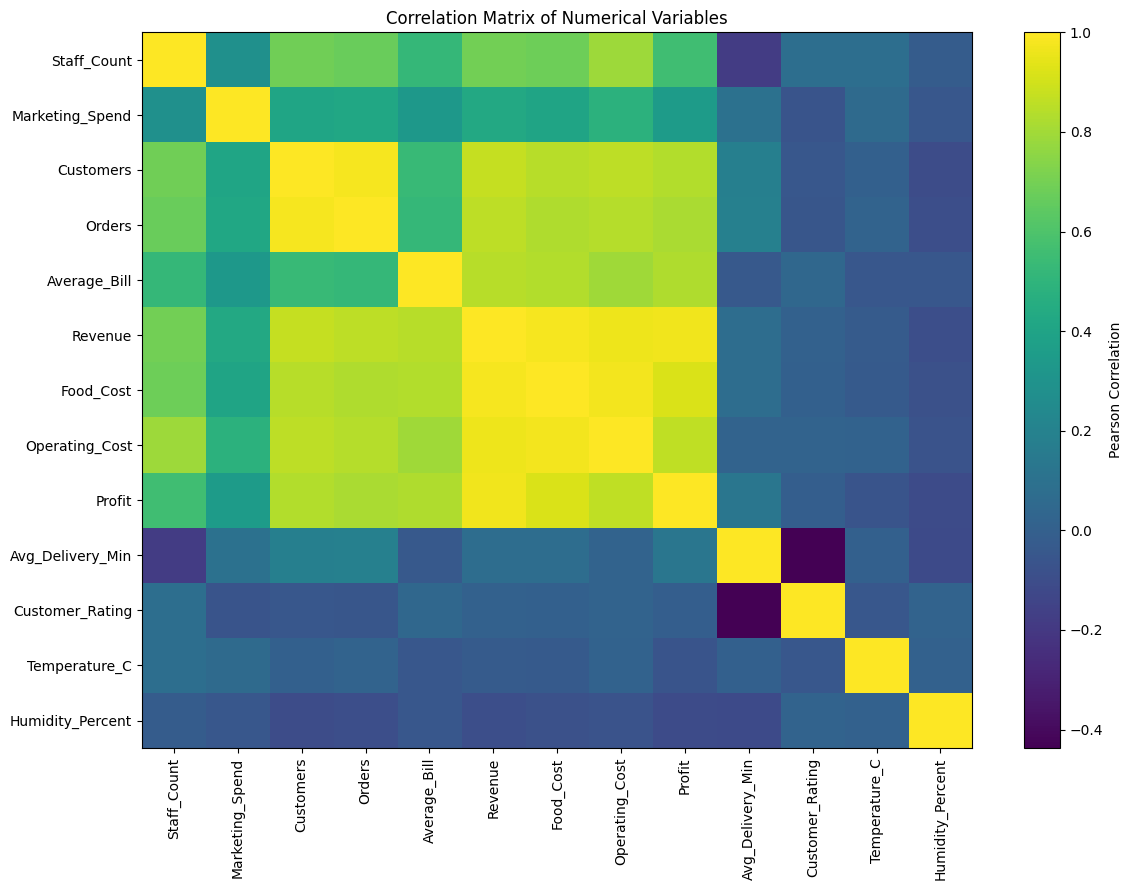

In [13]:
plt.figure(figsize=(12, 9))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Pearson Correlation")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

In [14]:
pairs = []
for i in range(len(num_cols)):
    for j in range(i + 1, len(num_cols)):
        pairs.append((num_cols[i], num_cols[j], correlation_matrix.iloc[i, j]))

strongest_pairs = (
    pd.DataFrame(pairs, columns=["Variable_1", "Variable_2", "Correlation"])
      .assign(Abs_Correlation=lambda x: x["Correlation"].abs())
      .sort_values("Abs_Correlation", ascending=False)
      .head(10)
)

display(strongest_pairs.round(3))

,Variable_1,Variable_2,Correlation,Abs_Correlation
23,Customers,Orders,0.980,0.980
50,Revenue,Food_Cost,0.979,0.979
57,Food_Cost,Operating_Cost,0.973,0.973
52,Revenue,Profit,0.967,0.967
51,Revenue,Operating_Cost,0.963,0.963
58,Food_Cost,Profit,0.918,0.918
25,Customers,Revenue,0.876,0.876
63,Operating_Cost,Profit,0.862,0.862
34,Orders,Revenue,0.858,0.858
27,Customers,Operating_Cost,0.856,0.856


Focused Relationship Analysis

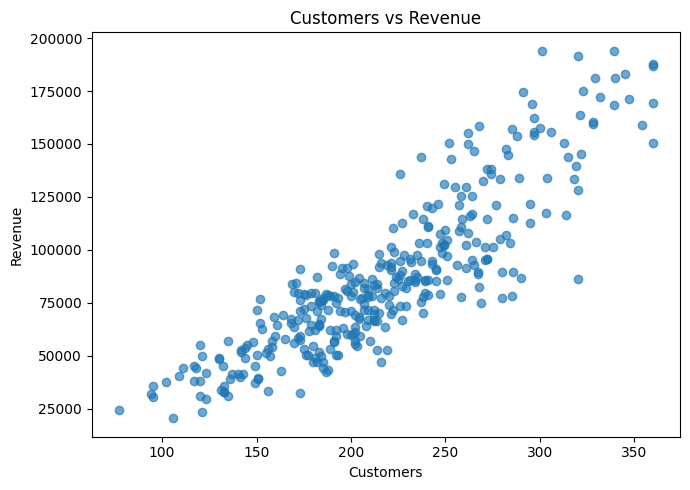

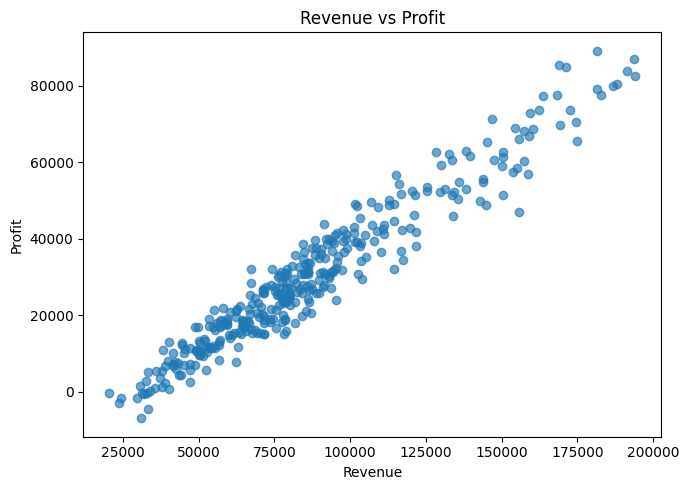

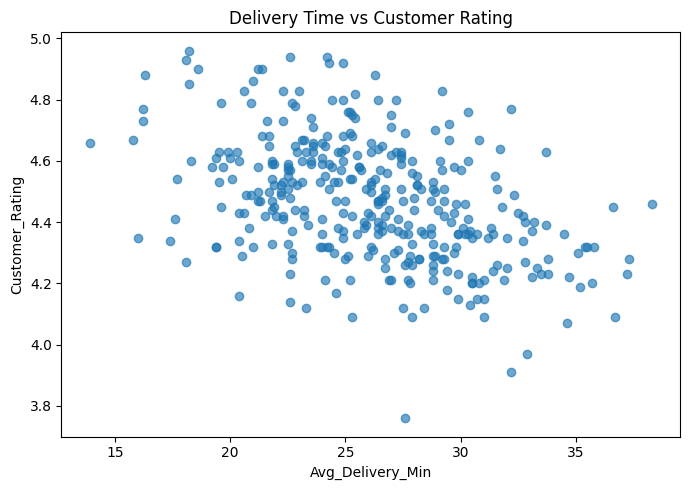

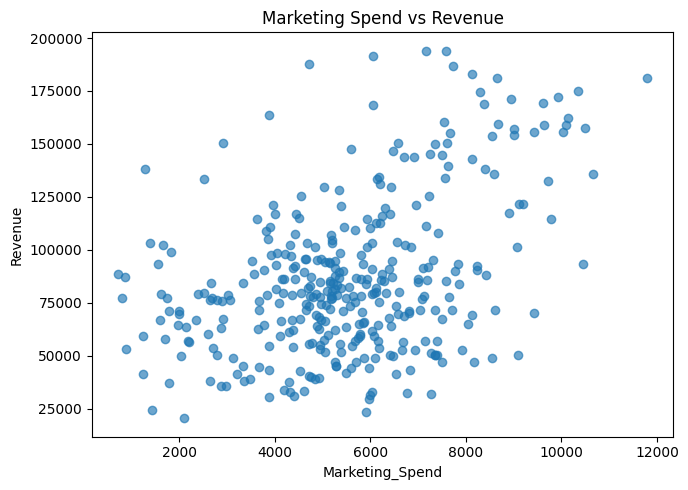

In [15]:
relationships = [
    ("Customers", "Revenue", "Customers vs Revenue"),
    ("Revenue", "Profit", "Revenue vs Profit"),
    ("Avg_Delivery_Min", "Customer_Rating", "Delivery Time vs Customer Rating"),
    ("Marketing_Spend", "Revenue", "Marketing Spend vs Revenue")
]

for x, y, title in relationships:
    plt.figure(figsize=(7, 5))
    plt.scatter(df[x], df[y], alpha=0.65)
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.tight_layout()
    plt.show()

## 10. Data-Driven Observations and Conclusion

1. **Customers and orders are tightly connected.** Their Pearson correlation is approximately **0.98**, so records with more customers generally have more orders.

2. **Revenue and profit have a very strong positive relationship.** Their correlation is approximately **0.97**. Across the full dataset, total profit is about **34.8% of total revenue**.

3. **Customer volume is an important financial performance indicator.** Customers correlate with Revenue at approximately **0.88** and with Profit at approximately **0.84**.

4. **Staff count is strongly associated with operational scale.** Staff Count correlates with Revenue at approximately **0.70** and with Customers at approximately **0.69**, suggesting larger-volume records tend to have more staff.

5. **Marketing spend and revenue have a moderate positive association.** Their correlation is approximately **0.43**. This relationship does not by itself prove that higher marketing spend causes higher revenue.

6. **Delivery time is inversely related to customer rating.** The correlation between Avg_Delivery_Min and Customer_Rating is approximately **-0.44**, indicating that longer delivery times tend to coincide with lower ratings.

7. **Branch performance differs across locations.** Based on average profit per record, **Bengaluru** is the strongest branch, while **Bengaluru** has the highest average revenue. **Pune** has the highest average customer rating.

8. **Store type is an important segmentation variable.** **Premium** has the highest average revenue and customer count. Premium stores average about **₹152,867 revenue per record**, compared with **₹87,269** for Standard and **₹52,327** for Express.

### Final takeaway

The EDA shows that **customer/order volume, staffing, revenue and profit are strongly interconnected**, while **delivery time has a noticeable inverse relationship with customer satisfaction**. Branch, region and store-type comparisons also reveal differences in operating scale and financial performance. These results can guide further analysis of profitability per order, marketing efficiency and delivery operations.